In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from nb_functions import random_guess, all_no, all_yes
import warnings 

warnings.filterwarnings('ignore')

### Load the dataset

In [97]:
raw_df = pd.read_csv(r'..\data\raw\weatherAUS.csv')
raw_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Data Processing

In [98]:
raw_df.shape

(145460, 23)

Drop all RainToday and RainTomorrow rows that are null. The values in these columns are important in determining whether it will rain the following day.

In [99]:
raw_df.dropna(subset=['RainToday', 'RainTomorrow'], inplace=True)

In [100]:
raw_df.shape

(140787, 23)

#### Split training, validation and test set

In [101]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]

In [102]:
print('train_df.shape: ', train_df.shape)
print('val_df.shape: ', val_df.shape)
print('test_df.shape: ', test_df.shape)

train_df.shape:  (97988, 23)
val_df.shape:  (17089, 23)
test_df.shape:  (25710, 23)


#### Load input, target, numerical and categorical columns.

In [103]:
aus_mod = joblib.load('..\\model\\aussie_rain.joblib')

input_cols = aus_mod['input_cols']
target_col = aus_mod['target_col']
numeric_cols = aus_mod['numeric_cols']
categorical_cols = aus_mod['categorical_cols']

In [104]:
train_inputs = train_df[input_cols].copy().reset_index(drop=True)
train_target = train_df[target_col].copy().reset_index(drop=True)

val_inputs = val_df[input_cols].copy().reset_index(drop=True)
val_target = val_df[target_col].copy().reset_index(drop=True)

test_inputs = test_df[input_cols].copy().reset_index(drop=True)
test_target = test_df[target_col].copy().reset_index(drop=True)

#### Imputting missing numerical columns

In [105]:
from sklearn.impute import SimpleImputer

In [106]:
train_inputs[numeric_cols].isna().sum()

MinTemp            314
MaxTemp            187
Rainfall             0
Evaporation      36331
Sunshine         40046
WindGustSpeed     6828
WindSpeed9am       874
WindSpeed3pm      1069
Humidity9am       1052
Humidity3pm       1116
Pressure9am       9112
Pressure3pm       9131
Cloud9am         34988
Cloud3pm         36022
Temp9am            574
Temp3pm            596
dtype: int64

Use median since it is more robust to outliers compared to the mean

In [107]:
imputer = SimpleImputer(strategy='median')

In [108]:
imputer.fit(train_inputs[numeric_cols])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['MinTemp','MaxTemp','Rainfall',...,'Cloud3pm','Temp9am','Temp3pm']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](16,)","[11.8,22.4, 0. ,..., 5. ,16.6,20.9]"


In [109]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [110]:
train_inputs[numeric_cols].isna().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

#### Scaling numeric features

In [111]:
from sklearn.preprocessing import StandardScaler

In [112]:
scaler = StandardScaler()

In [113]:
scaler.fit(train_inputs[numeric_cols])

StandardScaler()

In [114]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [115]:
train_inputs[input_cols]

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,0.219795,-0.017343,-0.208121,-0.137719,0.178827,W,0.292748,W,WNW,...,0.593031,0.124676,-1.428251,-1.456803,-1.205053,1.484560,0.172490,0.010375,0.038725,No
1,Albury,-0.727029,0.297945,-0.278554,-0.137719,0.178827,WNW,0.292748,NNW,WSW,...,0.366373,-1.303801,-1.282884,-1.026255,-1.099996,0.192948,0.172490,0.057354,0.405781,No
2,Albury,0.140893,0.383933,-0.278554,-0.137719,0.178827,WSW,0.444083,W,WSW,...,0.819690,-1.621241,-1.040608,-1.471649,-0.964923,0.192948,-1.216023,0.652425,0.244277,No
3,Albury,-0.442982,0.713552,-0.278554,-0.137719,0.178827,NE,-1.220609,SE,E,...,-1.106905,-1.250895,-1.718983,0.012997,-0.349590,0.192948,0.172490,0.198292,0.728790,No
4,Albury,0.866791,1.329797,-0.161166,-0.137719,0.178827,W,0.065744,ENE,NW,...,0.139715,0.706648,-0.895241,-0.996562,-1.370142,1.054023,1.561002,0.151313,1.198622,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97983,Uluru,0.772109,1.458778,-0.278554,-0.137719,0.178827,SSE,0.217080,ESE,SSE,...,0.819690,-2.467746,-1.864349,-0.506629,-0.799833,0.192948,0.172490,1.075239,1.506949,No
97984,Uluru,0.488062,1.974704,-0.278554,-0.137719,0.178827,NE,-0.690934,ENE,SW,...,0.139715,-2.785185,-2.106626,-0.729326,-1.130012,0.192948,0.172490,1.889546,1.947416,No
97985,Uluru,0.835230,2.118017,-0.278554,-0.137719,0.178827,ESE,-0.085592,ESE,SSE,...,-1.106905,-2.838092,-2.106626,-0.833251,-1.069980,0.192948,0.172490,2.014824,2.079556,No
97986,Uluru,1.277082,2.218336,-0.278554,-0.137719,0.178827,ESE,0.217080,ESE,SSW,...,-0.200272,-2.467746,-2.058170,-0.521476,-0.889882,0.192948,0.172490,2.030484,2.299790,No


In [116]:
train_inputs[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04,9.798800e+04
mean,-2.413241e-16,-1.206620e-16,-2.320424e-17,-2.459649e-16,1.392254e-17,-1.229825e-16,4.640847e-17,1.322641e-16,-1.949156e-16,8.353525e-17,4.998193e-15,-2.380755e-15,1.508275e-16,1.253029e-16,1.670705e-16,2.784508e-16
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-3.236112e+00,-3.886787e+00,-2.785536e-01,-1.596863e+00,-2.706241e+00,-2.582631e+00,-1.574418e+00,-2.126868e+00,-3.631690e+00,-2.494269e+00,-5.495041e+00,-5.422334e+00,-1.959738e+00,-2.141698e+00,-3.560051e+00,-3.910797e+00
25%,-7.112486e-01,-7.339067e-01,-2.785536e-01,-3.914830e-01,-1.605926e-01,-6.909344e-01,-7.918217e-01,-6.535890e-01,-6.160159e-01,-7.014200e-01,-6.105543e-01,-6.347440e-01,-6.681262e-01,-7.531857e-01,-7.256341e-01,-7.247511e-01
50%,-3.269149e-02,-8.899934e-02,-2.785536e-01,-1.377189e-01,1.788272e-01,-8.559159e-02,-1.210252e-01,2.638579e-02,7.176953e-02,2.541054e-02,-1.849369e-03,-4.402960e-03,1.929482e-01,1.724895e-01,-3.660455e-02,-9.341489e-02
75%,7.247676e-01,6.992208e-01,-1.846434e-01,1.794863e-01,4.164210e-01,4.440833e-01,5.497714e-01,5.930314e-01,7.595549e-01,6.553303e-01,6.365485e-01,6.259381e-01,6.234854e-01,6.353271e-01,6.994043e-01,6.700614e-01
max,3.454777e+00,3.594138e+00,4.327231e+01,2.454084e+01,2.147462e+00,7.178522e+00,8.152133e+00,7.732766e+00,1.658967e+00,2.351268e+00,3.487069e+00,3.672587e+00,1.915097e+00,2.023840e+00,3.659100e+00,3.606509e+00


#### Encode Categorical columns

In [117]:
from category_encoders import OneHotEncoder

In [118]:
train_inputs[categorical_cols].isna().sum()

Location          0
WindGustDir    6868
WindDir9am     7019
WindDir3pm     1952
RainToday         0
dtype: int64

In [119]:
encoder = OneHotEncoder(use_cat_names=True, handle_unknown='return_nan')

In [120]:
encoder.fit(train_inputs[categorical_cols])

,cols,"['Location', 'WindGustDir', ...]"
,handle_unknown,'return_nan'
,use_cat_names,True
,verbose,0
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,min_group_size,None
,min_group_name,None
,combine_min_nan_groups,None
Name,Type,Value


In [121]:
len(encoder.get_feature_names_out())

102

In [122]:
train_inputs_encoded = encoder.transform(train_inputs[categorical_cols])
val_inputs_encoded = encoder.transform(val_inputs[categorical_cols])
test_inputs_encoded = encoder.transform(test_inputs[categorical_cols])

### Saving processed data to disk

Combine processed numerical and categorical columns

In [123]:
train_inputs = pd.concat([train_inputs[numeric_cols], train_inputs_encoded], axis=1)
val_inputs = pd.concat([val_inputs[numeric_cols], val_inputs_encoded], axis=1)
test_inputs = pd.concat([test_inputs[numeric_cols], test_inputs_encoded], axis=1)


In [124]:
print(train_inputs.shape)
print(val_inputs.shape)
print(test_inputs.shape)

(97988, 118)
(17089, 118)
(25710, 118)


Save to disk

In [125]:
train_inputs.to_parquet(r'..\data\processed\train_inputs2.parquet')
val_inputs.to_parquet(r'..\data\processed\val_inputs2.parquet')
test_inputs.to_parquet(r'..\data\processed\test_inputs2.parquet')

pd.DataFrame(train_target).to_parquet(r'..\data\processed\train_target2.parquet')
pd.DataFrame(val_target).to_parquet(r'..\data\processed\val_target2.parquet')
pd.DataFrame(test_target).to_parquet(r'..\data\processed\test_target2.parquet')

### Train a base model

In [126]:
from sklearn.metrics import accuracy_score

In [127]:
print('Model performance by randomly predicting Yes or No: ')
print('Training:', accuracy_score(train_target, random_guess(train_inputs)))
print('Validation:', accuracy_score(val_target, random_guess(val_inputs)))
print('Test:', accuracy_score(test_target, random_guess(test_inputs)))

Model performance by randomly predicting Yes or No: 
Training: 0.4990509041923501
Validation: 0.5027210486277722
Test: 0.49906651108518085


In [128]:
print('Model performance by predicting No for all inputs: ')
print('Training:', accuracy_score(train_target, all_no(train_inputs)))
print('Validation:', accuracy_score(val_target, all_no(val_inputs)))
print('Test:', accuracy_score(test_target, all_no(test_inputs)))

Model performance by predicting No for all inputs: 
Training: 0.7775441890843777
Validation: 0.7906255485985136
Test: 0.7734344612991054


In [129]:
print('Model performance by predicting Yes for all inputs: ')
print('Training:', accuracy_score(train_target, all_yes(train_inputs)))
print('Validation:', accuracy_score(val_target, all_yes(val_inputs)))
print('Test:', accuracy_score(test_target, all_yes(test_inputs)))

Model performance by predicting Yes for all inputs: 
Training: 0.22245581091562233
Validation: 0.20937445140148633
Test: 0.2265655387008946


### Train a Logistic Regression model

#### Model Training

In [130]:
from sklearn.linear_model import LogisticRegression

In [131]:
lr_model = LogisticRegression(random_state=42)

In [132]:
lr_model.fit(train_inputs, train_target)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [133]:
feat_impor_df = pd.DataFrame({
  'Feature': train_inputs.columns, 
  'Weight': lr_model.coef_.tolist()[0]
})

In [134]:
fi_df_sort = feat_impor_df.sort_values(by='Weight', ascending=False)

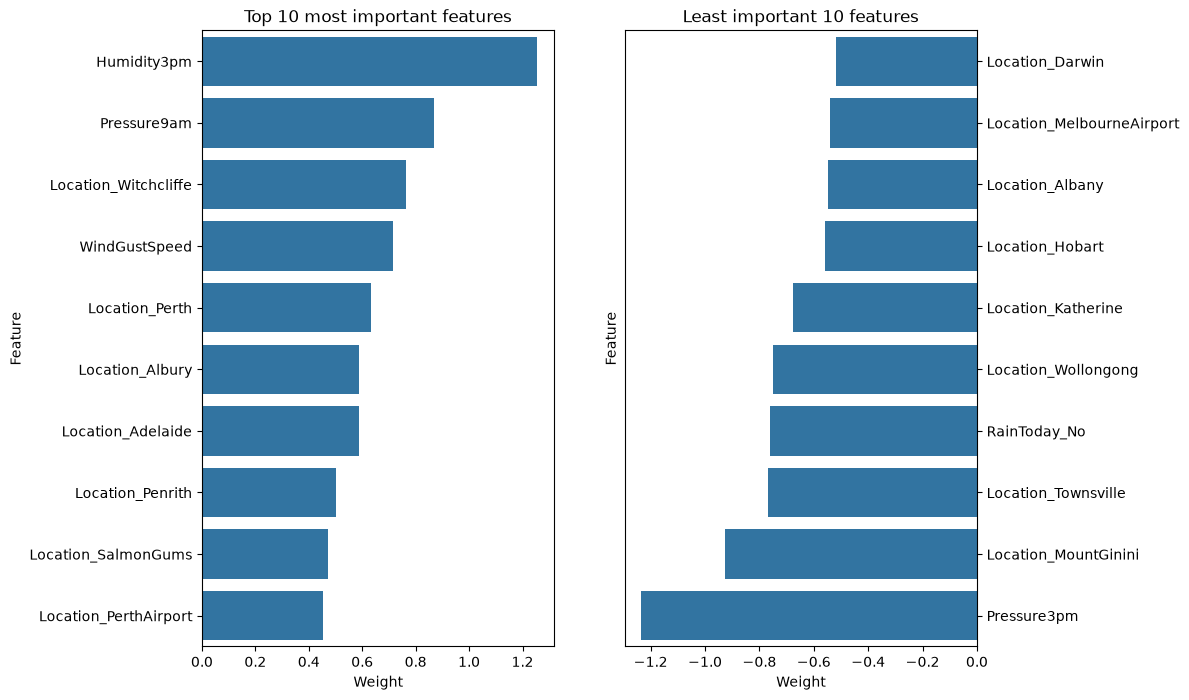

In [135]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))

sns.barplot(data=fi_df_sort.head(10), x='Weight', y='Feature', ax=ax[0])
ax[0].set_title('Top 10 most important features')
sns.barplot(data=fi_df_sort.tail(10), x='Weight', y='Feature', ax=ax[1])
ax[1].set_title('Least important 10 features')
ax[1].tick_params(
  axis='y',
  right=True, 
  labelright=True, 
  left=False,
  labelleft=False
)
plt.show()

#### Model Evaluation

In [136]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [137]:
train_preds = lr_model.predict(train_inputs)

In [138]:
accuracy_score(train_target, train_preds)

0.8520431073192636

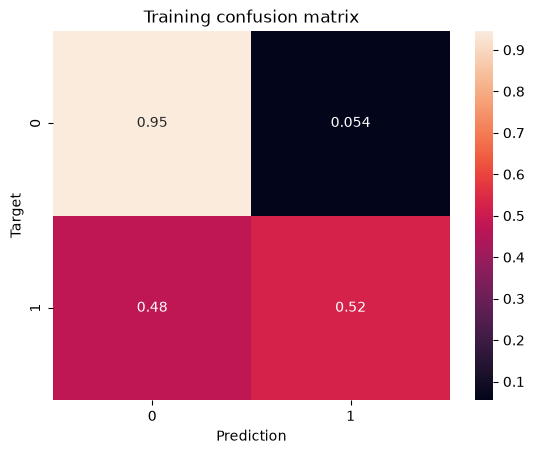

In [139]:
cm = confusion_matrix(train_target, train_preds, normalize='true')
sns.heatmap(cm, annot=True)
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title('Training confusion matrix')
plt.show()

In [140]:
val_preds = lr_model.predict(val_inputs)
accuracy_score(val_target, val_preds)

0.853765580197788

In [141]:
test_preds = lr_model.predict(test_inputs)
accuracy_score(test_target, test_preds)

0.8423181641384675

Logistic Regression Model Performance:
- Training: 85%
- Validation: 85%
- Test: 84%

### Training a Decision Tree Model

#### Model Training

In [142]:
from sklearn.tree import DecisionTreeClassifier

In [143]:
dt_model = DecisionTreeClassifier(random_state=42)

In [144]:
dt_model.fit(train_inputs, train_target)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Model Evaluation

In [145]:
train_preds = dt_model.predict(train_inputs)
accuracy_score(train_target, train_preds)

0.9999795893374699

In [146]:
val_preds = dt_model.predict(val_inputs)
accuracy_score(val_target, val_preds)

0.7957165428053133

Overfitting: Training and validation accuracy of 99% and 79% respectively

#### Hyperparameter tuning

In [147]:
dtt_model = DecisionTreeClassifier(max_depth=8, random_state=42)

In [148]:
dtt_model.fit(train_inputs, train_target)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [149]:
dtt_model.score(train_inputs, train_target), dtt_model.score(val_inputs, val_target)

(0.8551455280238397, 0.8457487272514483)

In [150]:
dtt_model.score(test_inputs, test_target)

0.8313107740178919

Decision Tree Model Performance  
- Training: 85%
- Validation: 84%
- Test: 83%

### Training a Random Forest Model

#### Train model with tuned hyperparameters

In [151]:
from sklearn.ensemble import RandomForestClassifier

In [152]:
rf_model = RandomForestClassifier(
  n_estimators=100, 
  min_samples_split=50, 
  min_samples_leaf=30, 
  max_features=60, 
  max_depth=15, 
  random_state=42
)

In [153]:
rf_model.fit(train_inputs, train_target)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",60
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

#### Model Evaluation

In [154]:
rf_model.score(train_inputs, train_target), rf_model.score(val_inputs, val_target)

(0.8695146344450341, 0.8538826145473697)

In [155]:
rf_model.score(test_inputs, test_target)

0.841656942823804

Random Forest Model Performance:  
- Training: 86%
- Validation: 85%
- Test: 84%

### Training a XGBoost Model

#### Model Training

In [156]:
from xgboost import XGBClassifier

In [157]:
xgb_model = XGBClassifier(random_state=42)

In [158]:
train_target.value_counts()

RainTomorrow
No     76190
Yes    21798
Name: count, dtype: int64

In [159]:
xgb_train_target = train_target.map({'No': 0, 'Yes': 1})
xgb_val_target = val_target.map({'No': 0, 'Yes': 1})
xgb_test_target = test_target.map({'No': 0, 'Yes': 1})

In [160]:
xgb_model.fit(train_inputs, xgb_train_target)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [161]:
xgb_model.score(train_inputs, xgb_train_target), xgb_model.score(val_inputs, xgb_val_target)

(0.8934767522553783, 0.8616653987945462)

In [162]:
xgb_model.score(test_inputs, xgb_test_target)

0.8534811357448464

#### Tune hyperparameters

In [163]:
xgbt_model = XGBClassifier(
  colsample_bytree=0.8,
  learning_rate=0.05,
  max_depth=3,
  n_estimators=100,
  subsample=0.8
)

In [164]:
xgbt_model.fit(train_inputs, xgb_train_target)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [165]:
xgbt_model.score(train_inputs, xgb_train_target), xgbt_model.score(val_inputs, xgb_val_target)

(0.8510429848552884, 0.8501375153607584)

In [166]:
xgbt_model.score(test_inputs, xgb_test_target)

0.8390509529366006

Best xgboost model:
- Training: 89%
- Validation: 86%
- Testing: 85%